In [1]:
import sys
sys.path.append("../src")
from storage import read_delta

corr = read_delta("gold", "thermal_event_corroboration")
weekly = read_delta("gold", "events_by_oblast_week")

In [3]:

print("corroboration rows:", len(corr))
print("weekly rows:", len(weekly))
print(corr.columns.tolist())
print(weekly.columns.tolist())

corroboration rows: 586
weekly rows: 3373
['oblast_name', 'day', 'n_events', 'fatalities', 'n_detections', 'total_frp', 'has_events', 'has_detections', 'corroborated', '_built_at']
['oblast_name', 'oblast_pcode', 'iso_year', 'iso_week', 'week_start', 'n_events', 'fatalities', '_built_at']


In [4]:
event_days = corr[corr["has_events"]]
print(f"Corroboration rate: {event_days['corroborated'].mean():.1%}  (expect ~80.3%)")

Corroboration rate: 80.3%  (expect ~80.3%)


## Exploratory Data Analysis
Before testing whether satellite fire detections corroborate reported conflict,
I investigate the structure, quality, and distributions of the two gold tables:

- `thermal_event_corroboration`: one row per oblast per day (June 2025 window)
- `events_by_oblast_week`: one row per oblast per ISO week (2022–2025)

## 1. Structure & Integrity

In [5]:
print("=== CORROBORATION (oblast-day) ===")
print(f"Shape: {corr.shape}")
corr.info()
print("\n=== WEEKLY EVENTS (oblast-week) ===")
print(f"Shape: {weekly.shape}")
weekly.info()

=== CORROBORATION (oblast-day) ===
Shape: (586, 10)
<class 'pandas.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   oblast_name     586 non-null    str    
 1   day             586 non-null    str    
 2   n_events        586 non-null    int64  
 3   fatalities      586 non-null    int64  
 4   n_detections    586 non-null    int64  
 5   total_frp       586 non-null    float64
 6   has_events      586 non-null    bool   
 7   has_detections  586 non-null    bool   
 8   corroborated    586 non-null    bool   
 9   _built_at       586 non-null    str    
dtypes: bool(3), float64(1), int64(3), str(3)
memory usage: 66.7 KB

=== WEEKLY EVENTS (oblast-week) ===
Shape: (3373, 8)
<class 'pandas.DataFrame'>
RangeIndex: 3373 entries, 0 to 3372
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----       

In [6]:
# Numeric summaries
print("Corroboration table:")
display(corr.describe())
print("\nWeekly events table:")
display(weekly.describe())

Corroboration table:


,n_events,fatalities,n_detections,total_frp
count,586.000000,586.000000,586.000000,586.000000
mean,11.873720,11.378840,18.000000,134.113584
std,19.938566,33.825593,46.656885,558.902617
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.242500
50%,1.000000,0.000000,4.000000,8.060000
75%,17.000000,3.000000,15.000000,52.195000
max,100.000000,198.000000,545.000000,6645.310000



Weekly events table:


,iso_year,iso_week,week_start,n_events,fatalities
count,3373.000000,3373.000000,3373,3373.000000,3373.000000
mean,2023.440854,25.667951,2023-12-01 03:30:53.898606,58.038541,58.557664
min,2022.000000,1.000000,2022-02-21 00:00:00,1.000000,0.000000
25%,2023.000000,13.000000,2023-01-23 00:00:00,2.000000,0.000000
50%,2023.000000,24.000000,2023-12-25 00:00:00,8.000000,0.000000
75%,2024.000000,38.000000,2024-10-07 00:00:00,72.000000,29.000000
max,2025.000000,52.000000,2025-07-07 00:00:00,659.000000,1400.000000
std,1.034897,14.645172,NaN,103.906700,165.158120


In [7]:
# Missing values
print("Missing values — corroboration:")
print(corr.isna().sum())
print("\nMissing values — weekly:")
print(weekly.isna().sum())

Missing values — corroboration:
oblast_name       0
day               0
n_events          0
fatalities        0
n_detections      0
total_frp         0
has_events        0
has_detections    0
corroborated      0
_built_at         0
dtype: int64

Missing values — weekly:
oblast_name     0
oblast_pcode    0
iso_year        0
iso_week        0
week_start      0
n_events        0
fatalities      0
_built_at       0
dtype: int64


## 2. Data-Quality Checks

Confirming the known quirks quantitatively: any null oblasts, the date coverage,
and whether counts contain impossible (negative) values.

In [8]:
# Date coverage
print("Corroboration day range:", corr["day"].min(), "->", corr["day"].max())
print("Weekly range:", weekly["week_start"].min(), "->", weekly["week_start"].max())

# Sanity: no negative counts
for df, name, cols in [
    (corr, "corr", ["n_events", "n_detections", "fatalities", "total_frp"]),
    (weekly, "weekly", ["n_events", "fatalities"]),
]:
    cols = [c for c in cols if c in df.columns]
    negs = (df[cols] < 0).sum().sum()
    print(f"{name}: negative values across {cols} = {negs}")

# Oblast coverage
print("\nDistinct oblasts — corroboration:", corr["oblast_name"].nunique())
print("Distinct oblasts — weekly:", weekly["oblast_name"].nunique())

Corroboration day range: 2025-06-01 -> 2025-06-30
Weekly range: 2022-02-21 00:00:00 -> 2025-07-07 00:00:00
corr: negative values across ['n_events', 'n_detections', 'fatalities', 'total_frp'] = 0
weekly: negative values across ['n_events', 'fatalities'] = 0

Distinct oblasts — corroboration: 27
Distinct oblasts — weekly: 27


## 3. Univariate Distributions

Event and detection counts are expected to be heavily right-skewed, where a few
high-intensity frontline days, many quiet ones. Confirming this justifies
the log scales and informs which correlation method is valid later.

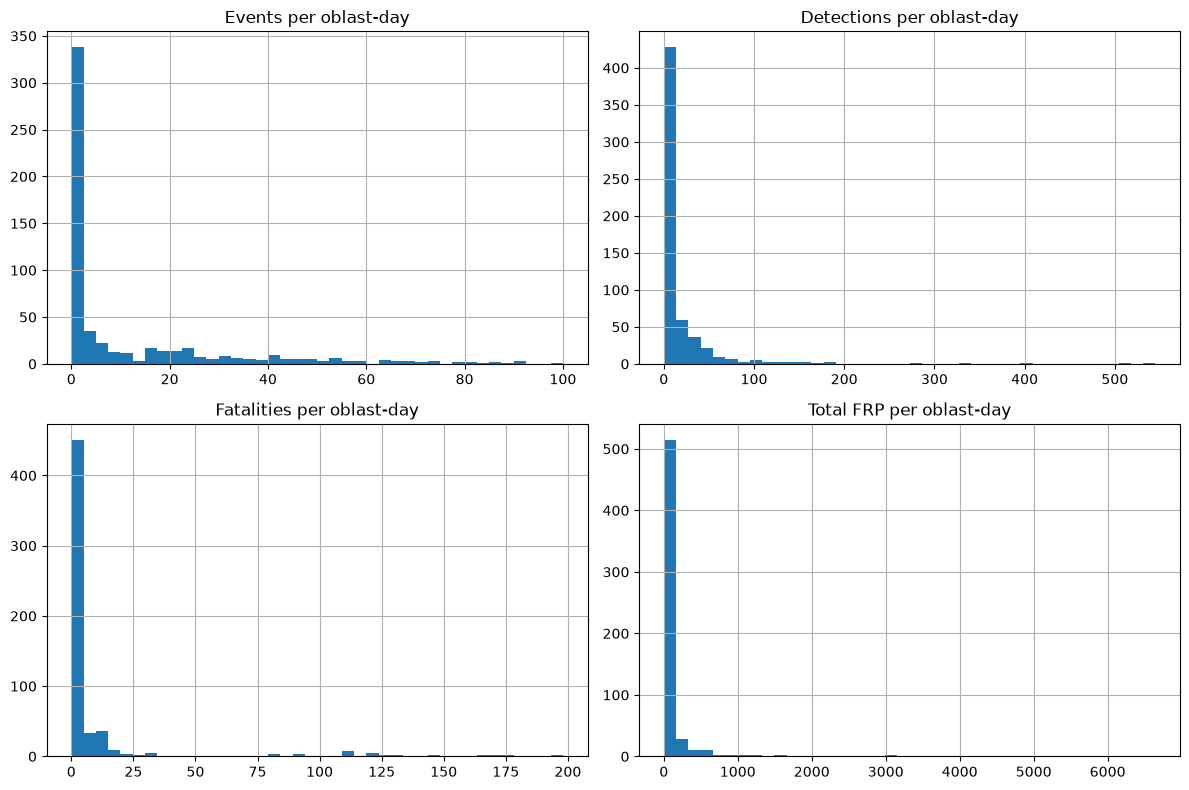

n_events        2.067823
n_detections    6.923370
fatalities      3.606877
total_frp       8.051767
dtype: float64


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
corr["n_events"].hist(bins=40, ax=axes[0, 0]);      axes[0, 0].set_title("Events per oblast-day")
corr["n_detections"].hist(bins=40, ax=axes[0, 1]);  axes[0, 1].set_title("Detections per oblast-day")
corr["fatalities"].hist(bins=40, ax=axes[1, 0]);    axes[1, 0].set_title("Fatalities per oblast-day")
corr["total_frp"].hist(bins=40, ax=axes[1, 1]);     axes[1, 1].set_title("Total FRP per oblast-day")
plt.tight_layout(); plt.show()

# Quantify the skew
print(corr[["n_events", "n_detections", "fatalities", "total_frp"]].skew())

## 4. Corroboration Composition

Every oblast-day falls into one of four states. This breakdown is the foundation
of the corroboration metric, and it reproduces the headline 80% rate.

In [10]:
# Four-way composition
def state(row):
    if row["has_events"] and row["has_detections"]: return "both"
    if row["has_events"]:  return "event only"
    if row["has_detections"]: return "detection only"
    return "neither"

corr["state"] = corr.apply(state, axis=1)
print(corr["state"].value_counts())
print("\nAs proportions:")
print(corr["state"].value_counts(normalize=True).round(3))

# Reproduce the headline rate (smoke test)
event_days = corr[corr["has_events"]]
print(f"\nCorroboration rate: {event_days['corroborated'].mean():.1%}  (expect ~80.3%)")

state
both              310
detection only    200
event only         76
Name: count, dtype: int64

As proportions:
state
both              0.529
detection only    0.341
event only        0.130
Name: proportion, dtype: float64

Corroboration rate: 80.3%  (expect ~80.3%)


## 5. Per-Oblast Summary

Aggregate to oblast level to surface the outliers statistically — especially
Kherson's high detection-to-event ratio (agricultural fires) and the
low-activity western oblasts.

In [14]:
import pandas as pd
oblast = (corr.groupby("oblast_name")
          .agg(events=("n_events", "sum"),
               detections=("n_detections", "sum"),
               fatalities=("fatalities", "sum"),
               corroboration_rate=("corroborated", "mean"),
               days=("day", "nunique"))
          .reset_index())
oblast["det_per_event"] = oblast["detections"] / oblast["events"].replace(0, pd.NA)
oblast = oblast.sort_values("events", ascending=False)
display(oblast.round(2))

,oblast_name,events,detections,fatalities,corroboration_rate,days,det_per_event
5,Donetsk Oblast,2204,1270,3221,1.00,30,0.576225
20,Sumy Oblast,1350,196,198,0.93,30,0.145185
8,Kherson Oblast,1162,4219,2437,0.97,30,3.630809
7,Kharkiv Oblast,688,360,336,0.97,30,0.523256
25,Zaporizhia Oblast,621,1162,259,1.00,30,1.871176
2,Chernihiv Oblast,391,49,12,0.50,30,0.12532
4,Dnipropetrovsk Oblast,211,963,119,1.00,30,4.563981
13,Luhansk Oblast,77,682,7,0.80,30,8.857143
11,Kyiv,54,81,42,0.25,24,1.5
15,Mykolaiv Oblast,48,493,5,0.60,30,10.270833


## 6. Does corroboration rate depend on evidence volume?

A high rate built on 2 event-days is not comparable to one built on hundreds.
Plotting rate against event-volume tests whether high rates in low-activity
oblasts are artifacts of small samples.

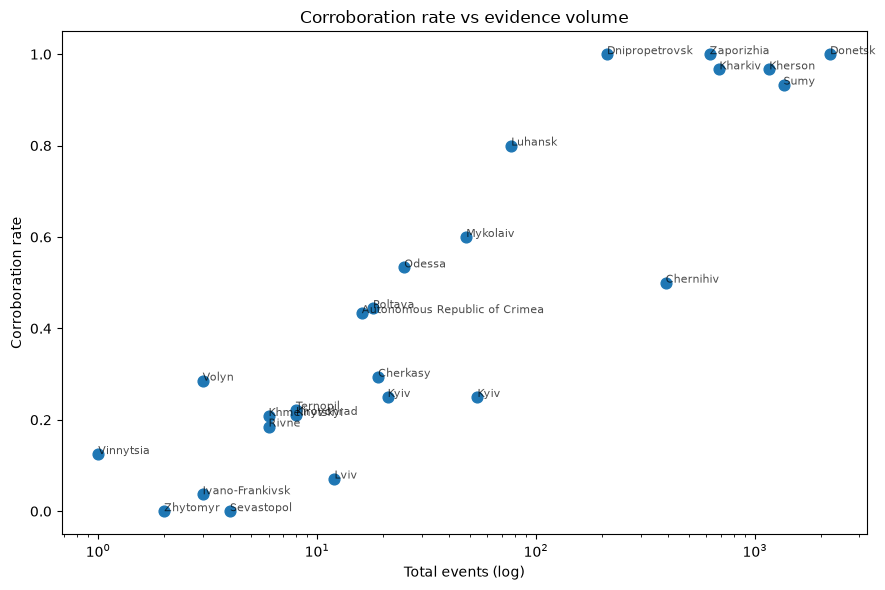

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(oblast["events"], oblast["corroboration_rate"], s=60)
for _, r in oblast.iterrows():
    ax.annotate(r["oblast_name"].replace(" Oblast", ""),
                (r["events"], r["corroboration_rate"]), fontsize=8, alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("Total events (log)"); ax.set_ylabel("Corroboration rate")
ax.set_title("Corroboration rate vs evidence volume")
plt.tight_layout(); plt.show()

# Statistical Analysis

## 7. Correlation: do events and detections move together?

We test the association at the **oblast-day** level. Because both variables are
heavily right-skewed, Spearman (rank) correlation is the primary measure;
Pearson is reported for comparison. Confidence intervals via bootstrap.

In [16]:
from scipy import stats
import numpy as np

# oblast-day level, within the overlap window
x = corr["n_events"].to_numpy()
y = corr["n_detections"].to_numpy()

pear_r, pear_p = stats.pearsonr(x, y)
spear_r, spear_p = stats.spearmanr(x, y)

print(f"Pearson  r = {pear_r:.3f}  (p = {pear_p:.2e})")
print(f"Spearman r = {spear_r:.3f}  (p = {spear_p:.2e})")

# Bootstrap 95% CI for Spearman
rng = np.random.default_rng(42)
boot = []
n = len(x)
for _ in range(5000):
    idx = rng.integers(0, n, n)
    boot.append(stats.spearmanr(x[idx], y[idx]).statistic)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Spearman 95% CI: [{lo:.3f}, {hi:.3f}]")

Pearson  r = 0.343  (p = 1.16e-17)
Spearman r = 0.407  (p = 8.08e-25)
Spearman 95% CI: [0.334, 0.472]


Spearman correlation matrix:


,n_events,fatalities,n_detections,total_frp
n_events,1.000,0.776,0.407,0.334
fatalities,0.776,1.000,0.516,0.469
n_detections,0.407,0.516,1.000,0.945
total_frp,0.334,0.469,0.945,1.000


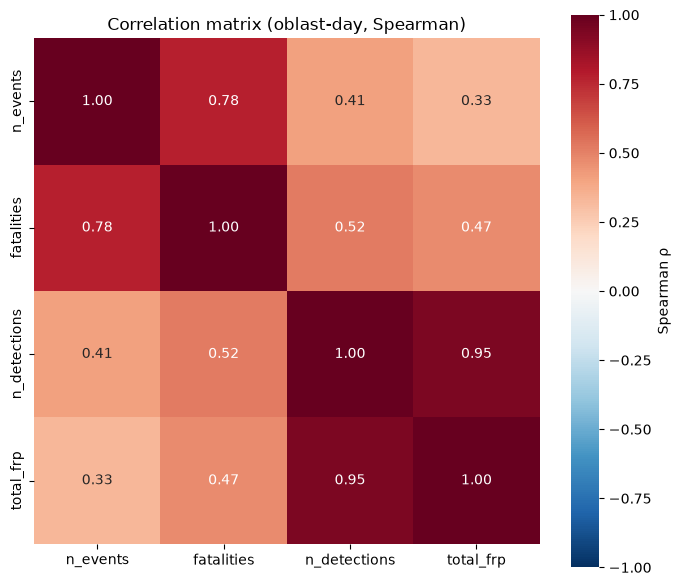

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# numeric columns of interest (drop flags and IDs)
num_cols = ["n_events", "fatalities", "n_detections", "total_frp"]
num_cols = [c for c in num_cols if c in corr.columns]

corr_matrix = corr[num_cols].corr(method="spearman")

print("Spearman correlation matrix:")
display(corr_matrix.round(3))

# heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={"label": "Spearman ρ"}, ax=ax)
ax.set_title("Correlation matrix (oblast-day, Spearman)")
plt.tight_layout(); plt.show()

### Interpretation checkpoint

- If Spearman is moderate/positive but well below 1, that quantifies "loosely
  correlate" — events and detections rise together, but weakly.
- A large Pearson–Spearman gap would confirm the relationship is non-linear
  (driven by a few high-intensity oblast-days), justifying the log scales.

## 8. Temporal lag: do fires follow fighting?

If shelling ignites fires, detections may lag events by a day or two. We build
daily national time series and cross-correlate at lags -3..+3 days.
Positive lag = detections follow events.

In [22]:
# aggregate to daily national totals (day is already datetime, June is complete)
corr["day"] = pd.to_datetime(corr["day"])
daily = (corr.groupby("day")
         .agg(events=("n_events", "sum"), detections=("n_detections", "sum"))
         .sort_index())

print("Totals:", daily["events"].sum(), daily["detections"].sum())   # expect 6958, 10548
print(f"Days: {len(daily)}\n")

ev = daily["events"].to_numpy()
de = daily["detections"].to_numpy()

def lagged_corr(a, b, lag):
    if lag > 0:
        return stats.spearmanr(a[:-lag], b[lag:]).statistic
    elif lag < 0:
        return stats.spearmanr(a[-lag:], b[:lag]).statistic
    return stats.spearmanr(a, b).statistic

print("lag(days)  Spearman(events_t, detections_t+lag)")
for lag in range(-3, 4):
    print(f"  {lag:+d}       {lagged_corr(ev, de, lag):.3f}")

Totals: 6958 10548
Days: 30

lag(days)  Spearman(events_t, detections_t+lag)
  -3       -0.038
  -2       -0.378
  -1       -0.022
  +0       0.095
  +1       0.141
  +2       0.328
  +3       0.349


In [23]:
for lag in [2, 3]:
    r, p = stats.spearmanr(ev[:-lag], de[lag:])
    print(f"lag +{lag}: rho={r:.3f}, p={p:.3f}")

lag +2: rho=0.328, p=0.088
lag +3: rho=0.349, p=0.075


### Interpretation checkpoint

- Peak correlation at **lag 0** → events and fires coincide same-day.
- Peak at **+1 / +2** → fires tend to follow reported events (supports a causal
  reading). Peak at negative lag → fires precede events (points to agricultural
  or other non-conflict drivers).

## 9. The agricultural-fire confound

Kherson's detections vastly outnumber its events. We quantify this per oblast:
a high detections-per-event ratio flags where the thermal signal is likely
dominated by non-conflict (agricultural) fires rather than combat.

In [24]:
conf = oblast[oblast["events"] >= 50].copy()   # meaningful conflict base only
conf = conf.sort_values("det_per_event", ascending=False)
print("Detections per event (oblasts with >=50 events):\n")
print(conf[["oblast_name", "events", "detections", "det_per_event",
            "corroboration_rate"]].to_string(index=False))

Detections per event (oblasts with >=50 events):

          oblast_name  events  detections det_per_event  corroboration_rate
       Luhansk Oblast      77         682      8.857143            0.800000
Dnipropetrovsk Oblast     211         963      4.563981            1.000000
       Kherson Oblast    1162        4219      3.630809            0.966667
    Zaporizhia Oblast     621        1162      1.871176            1.000000
                 Kyiv      54          81           1.5            0.250000
       Donetsk Oblast    2204        1270      0.576225            1.000000
       Kharkiv Oblast     688         360      0.523256            0.966667
          Sumy Oblast    1350         196      0.145185            0.933333
     Chernihiv Oblast     391          49       0.12532            0.500000
